In [195]:
pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/150.0 MB 825.8 kB/s eta 0:03:02
   ---------------------------------------- 0.5/150.0 MB 4.2 MB/s eta 0:00:36
   ---------------------------------------- 1.6/150.0 MB 9.3 MB/s eta 0:00:16
    --------------------------------------- 3.0/150.0 MB 14.9 MB/s eta 0:00:10
   - -------------------------------------- 4.5/150.0 MB 17.1 MB/s eta 0:00:09
   - -------------------------------------- 6.2/150.0 MB 19.9 MB/s eta 0:00:08
   -- ------------------------------------- 7.7/150.0 MB 22.5 MB/s eta 0:00:07
   -- ------------------------------------- 8.6/150.0 MB 21.2 MB/s eta 0:00:07
   -- ------------------------------------- 10.0/150.0 MB 22.0 MB/s eta 0:00:07
   --- ------------------------------------ 11.3/150.0 MB 28.5 MB/s eta 0:00:05
   --- ------------------------------------ 12.9/150.0 MB 29.7 MB/s

In [197]:
#Import Libraries
import pandas as pd #used for data processing
import numpy as np #used for data processing
import matplotlib.pyplot as plt # data visualisation
import seaborn as sns # data visualisation
import missingno as msno # missing data = data visualition
from collections import Counter #Counting

# Data Pre-Processsung
from sklearn.model_selection import train_test_split 
#from sklearn.preprocessing import MinMaxScaler


# Classifier Libraries
from sklearn.linear_model import SGDClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression

# pip install xgboost
from xgboost import XGBClassifier 
from sklearn.svm import LinearSVC, SVC 
from sklearn.naive_bayes import GaussianNB 
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier 
from sklearn.svm import LinearSVC, SVC 
from sklearn.naive_bayes import GaussianNB 
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score 
from sklearn.metrics import confusion_matrix

import warnings
warnings. filterwarnings ("ignore")

In [6]:
#load the Dataset
df = pd.read_csv(r"C:\Users\USER\OneDrive - Sheffield Hallam University\Documents\Data Science\capstone\Customer-Churn.csv")

In [8]:
#print the top rows
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
#print the bottom row
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [12]:
# Dimensionality of the data- The number of rows and column
df.shape

(7043, 21)

In [14]:
#Examine the column/features of the data
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [22]:
#investigate a data set for annomalies and data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


From the investiagation, the total Chargers is an Object and needs to be converted to a float, for proper analysis

In [20]:
#Covert the total charges from an Object to a float.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [26]:
#Check for null values
df.isna().sum()
#True = 1
#False = 0

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

the Total Charges has 11 missing values

In [28]:
#check where TotalCharges is na
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Where TotalCharges is Nan the Tenure is zero meaning those individuals with 0 Tenure do not have any  total charges ie they are new customers.

In [31]:
#fill the missing value NaN with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [33]:
#Check if 
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

The Data is clean and has no missing values

### Statiscal Analysis
### Numerical

In [39]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Categorical Data

In [42]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


### Univariate Analysis

In [45]:
categorical_features =  df.select_dtypes(include="object")
numerical_features = df.select_dtypes(exclude="object")

In [47]:
##list out the numerical features
numerical_features.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

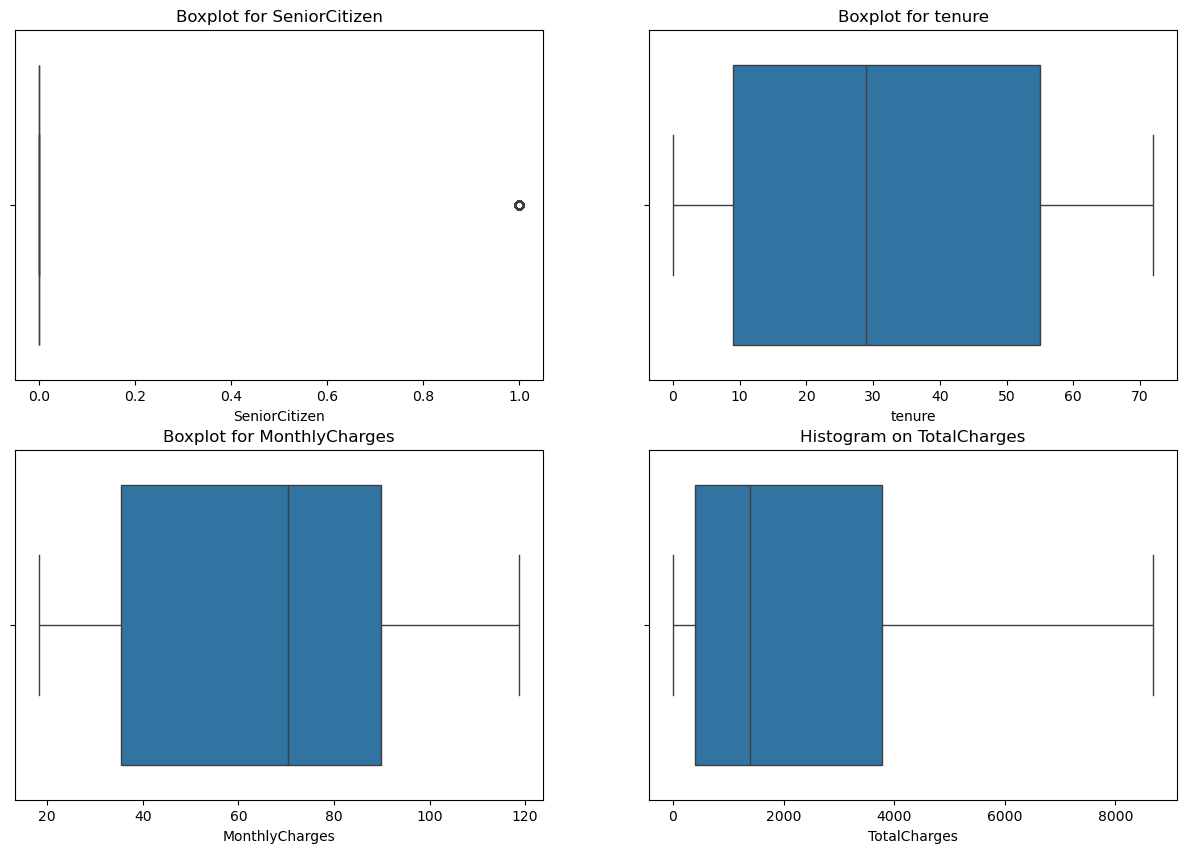

In [51]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15,10))

sns.boxplot(x="SeniorCitizen", data=df, ax=axs[0,0])
axs[0,0].set_title("Boxplot for SeniorCitizen")

sns.boxplot(x="tenure", data=df, ax=axs[0,1])
axs[0,1].set_title("Boxplot for tenure")

sns.boxplot(x="MonthlyCharges", data=df, ax=axs[1,0])
axs[1,0].set_title("Boxplot for MonthlyCharges")

sns.boxplot(x="TotalCharges", data=df, ax=axs[1,1])
axs[1,1].set_title("Histogram on TotalCharges");

This is box plot showing numerical features, for the senior citizen is either the customer is either a senior citizen or not which indicates 1 & 0. The box plot for tenure shows that there are more customer who have shorter tenure between 9 to 56 weeks. for the Monthly charges, it shows more customer pay a montly charge between 35 to 90.

In [53]:
#list out the categorical data
categorical_features.columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [147]:
#Drop CustomerID because it is not revelant for this analysis
categorical_features.drop(columns="customerID" , inplace=True)

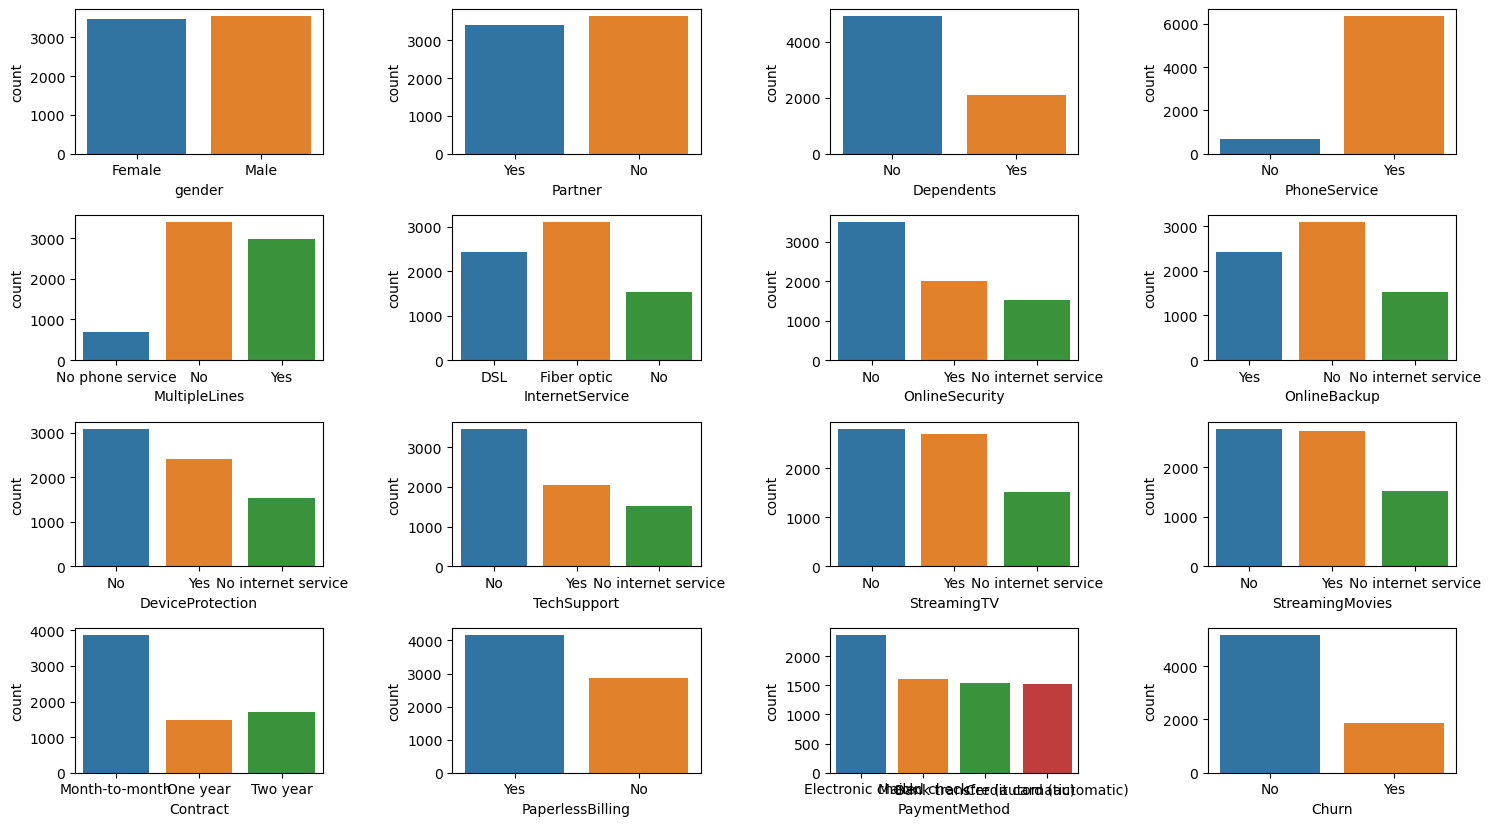

In [77]:
plt.figure(figsize=(15,10))

for i, column in enumerate(categorical_features, 1):
    plt.subplot(5,4,i)
    sns.countplot(data=categorical_features, x=column, hue=column)
plt.tight_layout()
plt.show()

This shows distribution of all the categorical features

### Bivariate Analysis

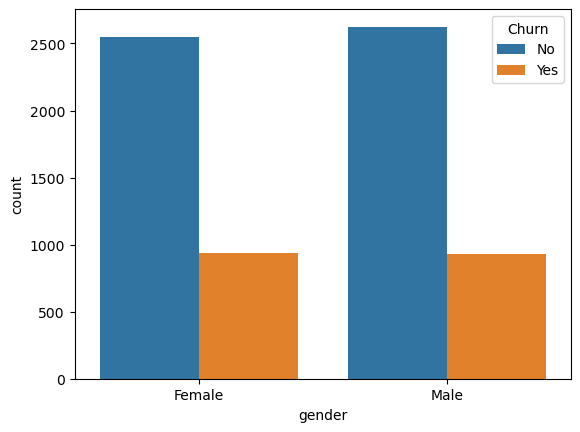

In [93]:
#Bivariate Analysis
## Categorical and cateogrical
sns.countplot(data=categorical_features, x="gender", hue="Churn");

A Bivariate analysis between the label feature (Churn) and gender, its a slight that the male has no churn more than the female and they both have equal churn

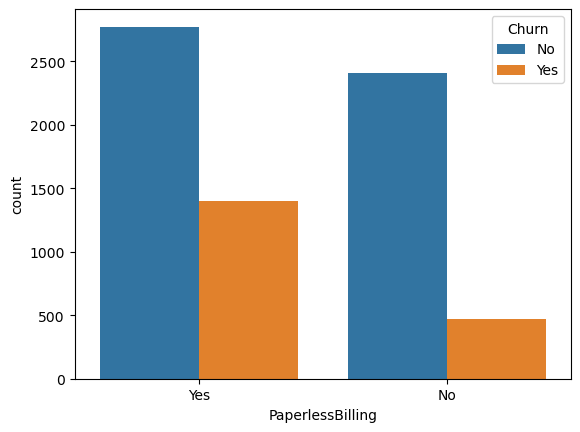

In [96]:
sns.countplot(data=categorical_features, x="PaperlessBilling", hue="Churn");

This analysis shows that those who use paperbilling has more churn than those who doesnt 

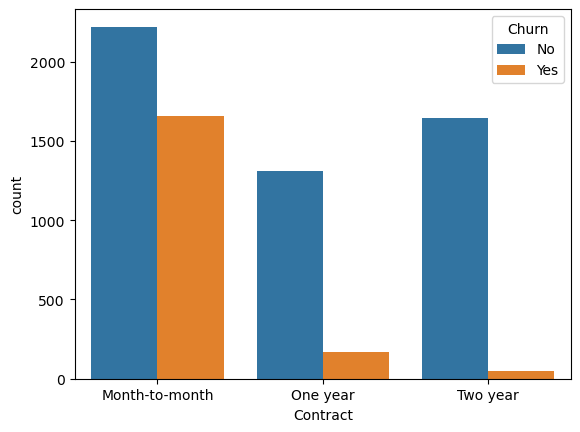

In [98]:
sns.countplot(data=categorical_features, x="Contract", hue="Churn");

For Contract, those on a  month to month contract has higher churn compared to the one year and two years individuals, those on a 2 years contract has less churn and are more table customer. i would suggest that we offer 2 years contract to those on a month to month and new customers aswell

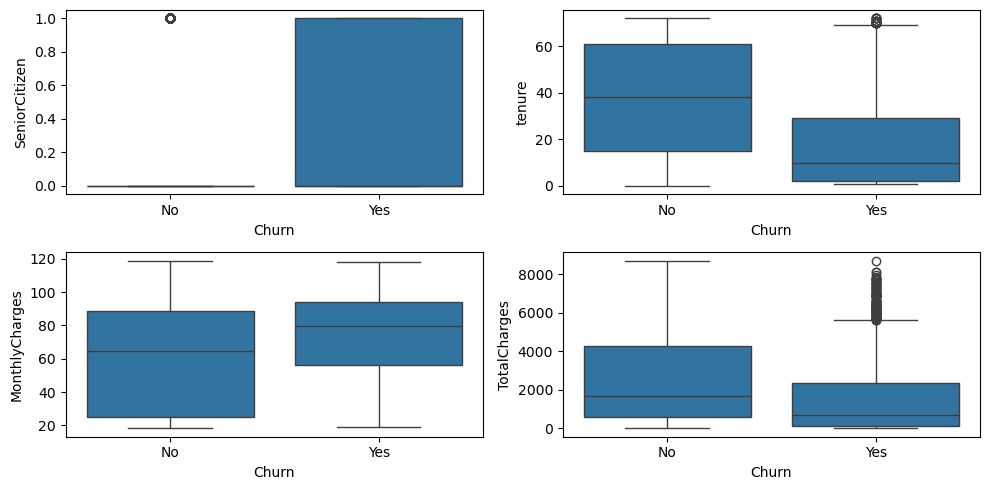

In [117]:
##Numerical and categorical 
plt.figure(figsize=(10,5))

for i, column in enumerate(numerical_features, 1):
    plt.subplot(2,2,i)
    sns.boxplot(data=numerical_features, y=column, x = df["Churn"])

plt.tight_layout()
plt.show()

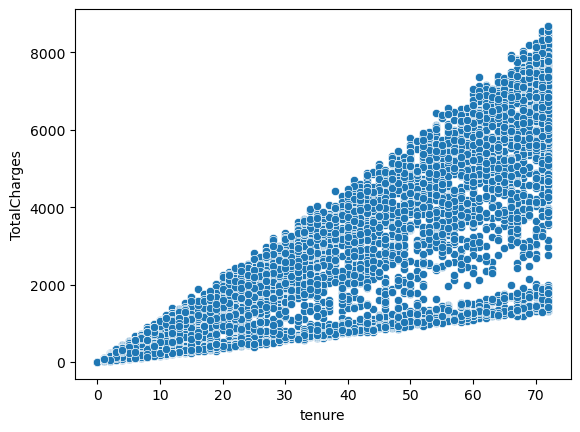

In [113]:
##Numerical and Numerical Analysis
sns.scatterplot(data= df, x="tenure", y="TotalCharges");

This shows a scatter plot between the total charges and tenure. it shows that customers who stay longer pay more montly charges.

### Machine learning

### Encoding the categorical features

In [123]:
from sklearn.preprocessing import LabelEncoder

In [125]:
categorical_features.columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [159]:
# Label encoding for binary categories
label_enc = LabelEncoder()
df['gender'] = label_enc.fit_transform(df['gender'])  
df['Partner'] = label_enc.fit_transform(df['Partner'])
df['Churn'] = label_enc.fit_transform(df['Churn'])
df['Dependents'] = label_enc.fit_transform(df['Dependents'])
df['PaperlessBilling'] = label_enc.fit_transform(df['PaperlessBilling'])
df['PhoneService'] = label_enc.fit_transform(df['PhoneService'])
df['InternetService'] = label_enc.fit_transform(df['InternetService'])
df['MultipleLines'] = label_enc.fit_transform(df['MultipleLines'])  
df['OnlineSecurity'] = label_enc.fit_transform(df['OnlineSecurity'])
df['OnlineBackup'] = label_enc.fit_transform(df['OnlineBackup'])
df['DeviceProtection'] = label_enc.fit_transform(df['DeviceProtection'])
df['TechSupport'] = label_enc.fit_transform(df['TechSupport'])
df['StreamingTV'] = label_enc.fit_transform(df['StreamingTV'])
df['Contract'] = label_enc.fit_transform(df['Contract'])
df['StreamingMovies'] = label_enc.fit_transform(df['StreamingMovies'])
df['PaymentMethod'] = label_enc.fit_transform(df['PaymentMethod'])

This convert the categorical features into a format for machine learning

In [163]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0


### Scale Numerical Features
Scale numerical columns to bring them to a similar range, which can improve model performance..

In [171]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [173]:
numerical_features.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [179]:
scaler = StandardScaler()
num_cols_to_scale = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols_to_scale] = scaler.fit_transform(df[num_cols_to_scale])

In [183]:
# Verify scaling
df[num_cols_to_scale].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7.043000e+03,7.043000e+03,7.043000e+03,7.043000e+03
mean,-4.842546e-17,-2.421273e-17,-6.406285e-17,-3.783239e-17
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-4.399165e-01,-1.318165e+00,-1.545860e+00,-1.005780e+00
25%,-4.399165e-01,-9.516817e-01,-9.725399e-01,-8.299464e-01
50%,-4.399165e-01,-1.372744e-01,1.857327e-01,-3.905282e-01
75%,-4.399165e-01,9.214551e-01,8.338335e-01,6.648034e-01
max,2.273159e+00,1.613701e+00,1.794352e+00,2.825806e+00


In [185]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [187]:
## Create a copy of the data(exclusing Churn and other irrelevant features)
df1 = df[["gender", "SeniorCitizen", "Partner", "Dependents", "tenure", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod", "MonthlyCharges","TotalCharges" ]]
label = df[["Churn"]]

In [189]:
df1.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,-0.439916,1,0,-1.277445,0,1,0,0,2,0,0,0,0,0,1,2,-1.160323,-0.992611
1,1,-0.439916,0,0,0.066327,1,0,0,2,0,2,0,0,0,1,0,3,-0.259629,-0.172165


In [191]:
label.head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [193]:
df1.dtypes

gender                int64
SeniorCitizen       float64
Partner               int64
Dependents            int64
tenure              float64
PhoneService          int64
MultipleLines         int32
InternetService       int64
OnlineSecurity        int32
OnlineBackup          int32
DeviceProtection      int32
TechSupport           int32
StreamingTV           int32
StreamingMovies       int32
Contract              int32
PaperlessBilling      int64
PaymentMethod         int32
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [199]:
# split the dataset into training and testing sets - x = Questions, y = Answers
x_train, x_test, y_train, y_test = train_test_split(df1, label, test_size=0.2, random_state=42)

In [201]:
# Model Building
# Logistic Regression

logreg = LogisticRegression()
logreg.fit(x_train, y_train)
ly_pred = logreg.predict(x_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, ly_pred))
print("Precision:", precision_score(y_test, ly_pred))
print("Recall:", recall_score(y_test, ly_pred))
print("F1-score:", f1_score(y_test, ly_pred))
print("AUC-ROC:", roc_auc_score(y_test, ly_pred))

Logistic Regression
Accuracy: 0.8168914123491838
Precision: 0.6802507836990596
Recall: 0.5817694369973191
F1-score: 0.6271676300578035
AUC-ROC: 0.7416569192708604


Using Logistic Regression, i trained the model and also fed it the answers. It shows the accuracy, precision, recall, f1-score, auc-roc

In [204]:
x_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
185,0,-0.439916,1,0,-1.277445,0,1,0,0,0,0,0,0,0,0,1,2,-1.328164,-0.994838
2715,1,-0.439916,0,0,0.351370,1,2,2,1,1,1,1,1,1,0,1,0,-1.313208,-0.566163
3825,0,-0.439916,1,1,0.799294,1,0,2,1,1,1,1,1,1,2,0,3,-1.509300,-0.550611
1807,0,-0.439916,0,0,-1.277445,1,0,1,0,0,2,0,0,0,0,0,2,0.385148,-0.972096
132,1,-0.439916,0,0,1.410099,1,0,0,0,0,0,2,0,0,2,0,0,-0.472339,0.432521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6366,0,-0.439916,1,0,1.287938,1,0,0,0,2,2,2,0,2,2,1,3,0.117599,0.926072
315,1,-0.439916,1,1,0.758574,1,2,1,2,2,0,2,2,2,1,0,1,1.505199,1.502963
2439,1,-0.439916,1,1,-0.625919,1,0,2,1,1,1,1,1,1,1,0,0,-1.491021,-0.860300
5002,0,-0.439916,1,1,1.491540,0,1,0,2,0,2,0,0,2,2,1,1,-0.691696,0.300166


In [208]:
print(ly_pred[:10])

[1 0 0 1 0 0 0 0 0 0]


In [210]:
print(y_test[:10])

      Churn
185       1
2715      0
3825      0
1807      1
132       0
1263      1
3732      0
1672      0
811       1
2526      1


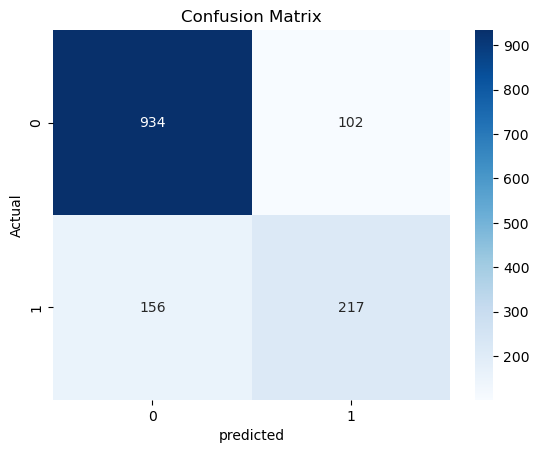

In [212]:
# Create a confusion matrix
lcm = confusion_matrix(y_test, ly_pred)

#Visualize the confusion matrix
sns.heatmap(lcm, annot=True, cmap="Blues", fmt="g")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Heat map of Logistic Regression. Displays the predicted and actual values.

In [215]:
# Model Building
# Random Forest Classifier
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)
rfy_pred = rfc.predict(x_test) 
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, rfy_pred))
print("Precision:", precision_score(y_test, rfy_pred))
print("Recall:", recall_score(y_test, rfy_pred))
print("F1-score:", f1_score(y_test, rfy_pred))
print("AUC-ROC:", roc_auc_score(y_test, rfy_pred))

Logistic Regression
Accuracy: 0.8005677785663591
Precision: 0.6755725190839694
Recall: 0.4745308310991957
F1-score: 0.5574803149606299
AUC-ROC: 0.6962422495264319


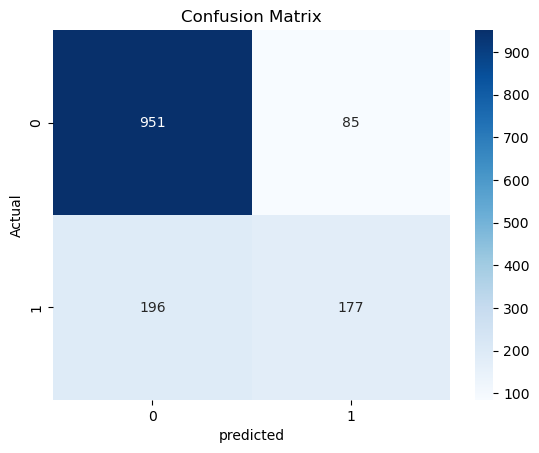

In [217]:
rcm = confusion_matrix(y_test, rfy_pred)

#Visualize the confusion matrix
sns.heatmap(rcm, annot=True, cmap="Blues", fmt="g")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [219]:
# Using for loop to loop through the classifiers
classifiers = [[XGBClassifier(), 'XGB Classifier'],
               [RandomForestClassifier(), 'Random Forest'],
               [KNeighborsClassifier(), 'K-Nearest Classifier'],
               [SGDClassifier(), 'SGDC Classifier'],
               [SVC(), 'SVC'],
               [GaussianNB(), 'Naive Rayes'],
               [DecisionTreeClassifier(random_state = 42), "Decision tree"],
               [LogisticRegression(), "Logistic Regression"]
              ]  

In [221]:
classifiers

[[XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...),
  'XGB Classifier'],
 [RandomForestClassifier(), 'Random Forest'],
 [KNeighborsClassifier(), 'K-Nearest Classifier'],
 [SGDClassifier(), 'SGDC Classifier'],
 [SVC(), 'SVC'],
 [GaussianNB(), 'Naive Rayes'],
 [Decision

In [223]:
# Loop through multiple models
acc_list = {}
precision_list = {}
recall_list = {}
roc_list = {}

for classifier in classifiers:
    model = classifier[0]
    model.fit(x_train, y_train)
    model_name = classifier[1]

    pred = model.predict(x_test)

    a_score = accuracy_score(y_test, pred)
    p_score = precision_score(y_test, pred)
    r_score = recall_score(y_test, pred)
    p_score = roc_auc_score(y_test, pred)

    acc_list[model_name] = ([str(round(a_score*100, 2)) + '%'])
    precision_list[model_name] = ([str(round(p_score*100, 2)) + '%'])
    recall_list[model_name] = ([str(round(r_score*100, 2)) + '%'])
    roc_list[model_name] = ([str(round(r_score*100, 2)) + '%'])

    if model_name != classifiers[-1][1]:
        print('')

In [225]:
# accuracy
acc_list

{'XGB Classifier': ['78.99%'],
 'Random Forest': ['80.13%'],
 'K-Nearest Classifier': ['76.44%'],
 'SGDC Classifier': ['76.3%'],
 'SVC': ['81.41%'],
 'Naive Rayes': ['75.8%'],
 'Decision tree': ['72.46%'],
 'Logistic Regression': ['81.69%']}

In [227]:
print("Precision")
s2 = pd.DataFrame(precision_list)
s2.head()

Precision


,XGB Classifier,Random Forest,K-Nearest Classifier,SGDC Classifier,SVC,Naive Rayes,Decision tree,Logistic Regression
0,70.27%,70.02%,67.76%,58.23%,71.57%,76.34%,65.49%,74.17%


In [229]:
print("Recall")
s3 = pd.DataFrame(recall_list)
s3.head()

Recall


,XGB Classifier,Random Forest,K-Nearest Classifier,SGDC Classifier,SVC,Naive Rayes,Decision tree,Logistic Regression
0,51.74%,48.53%,49.33%,19.84%,50.67%,77.48%,50.67%,58.18%


In [231]:
print("Roc score")
s4 = pd.DataFrame(roc_list)
s4.head()

Roc score


,XGB Classifier,Random Forest,K-Nearest Classifier,SGDC Classifier,SVC,Naive Rayes,Decision tree,Logistic Regression
0,51.74%,48.53%,49.33%,19.84%,50.67%,77.48%,50.67%,58.18%


Rather than go through each classifier one by one, i'll put them in a for loop to make the whole process efficient.

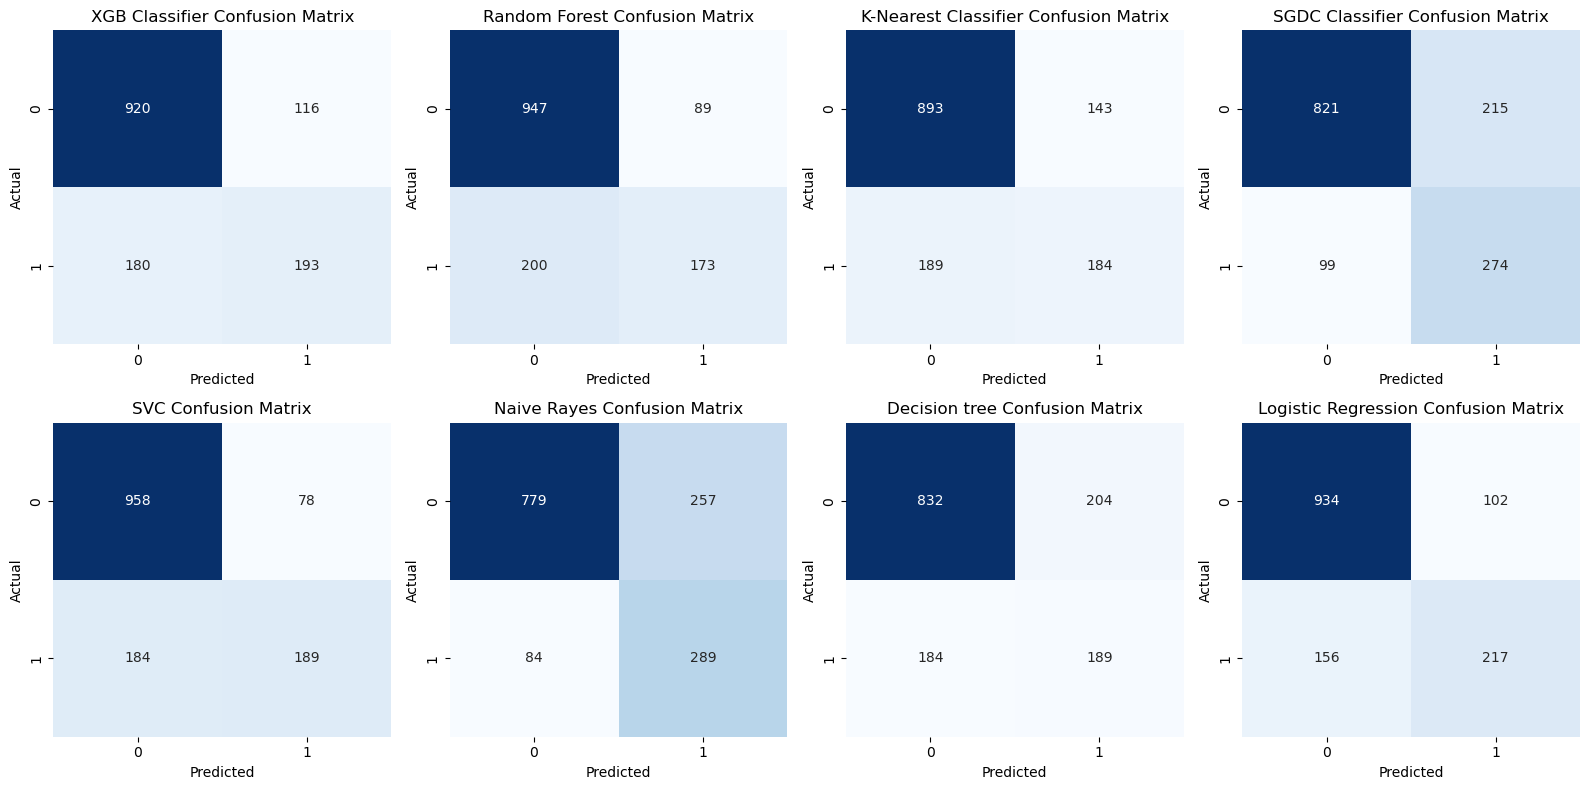

                      Accuracy  Precision  Recall  ROC AUC
XGB Classifier           78.99      62.46   51.74    70.27
Random Forest            79.49      66.03   46.38    68.89
K-Nearest Classifier     76.44      56.27   49.33    67.76
SGDC Classifier          77.71      56.03   73.46    76.35
SVC                      81.41      70.79   50.67    71.57
Naive Rayes              75.80      52.93   77.48    76.34
Decision tree            72.46      48.09   50.67    65.49
Logistic Regression      81.69      68.03   58.18    74.17


In [234]:
# Initialize lists to store the scores
acc_list = {}
precision_list = {}
recall_list = {}
roc_list = {}

# Initialize the plot for confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # Adjust the layout based on number of classifiers
axes = axes.flatten()  # Flatten the 2D array to make indexing easier

# Loop through the classifiers
for idx, classifier in enumerate(classifiers):
    model = classifier[0]
    model_name = classifier[1]

    # Train the model
    model.fit(x_train, y_train)
    
    # Make predictions
    pred = model.predict(x_test)
    # Calculate performance metrics
    a_score = accuracy_score(y_test, pred)
    p_score = precision_score(y_test, pred)
    r_score = recall_score(y_test, pred)
    roc_score = roc_auc_score(y_test, pred)

    # Store metrics in dictionaries
    acc_list[model_name] = round(a_score * 100, 2)
    precision_list[model_name] = round(p_score * 100, 2)
    recall_list[model_name] = round(r_score * 100, 2)
    roc_list[model_name] = round(roc_score * 100, 2)

    # Plot the confusion matrix
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx]), 

    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_title(f"{model_name} Confusion Matrix")

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

# Create a DataFrame with the results
results_df = pd.DataFrame({
    'Accuracy': acc_list,
    'Precision': precision_list,
    'Recall': recall_list,
    'ROC AUC': roc_list
})

# Print the results DataFrame
print(results_df)

In [ ]:
Based on the evaluation of the models, the following insights were drawn for customer Churn prediction:

Accuracy: The model with the highest accuracy is XGB Classifier, indicating it correctly predicts the most instances.

Precision: XGB Classifier also achieved the best precision, minimizing false positives.

Recall: XGB Classifier performed best in recall, effectively identifying true positives.

ROC AUC: XGB Classifier also led in ROC AUC, showing the best balance between sensitivity and specificity.

Overall, XGB Classifier is the most reliable model for this dataset based on these metrics.